In [1]:
import os
import sys

os.chdir('../..')
sys.path.append(os.getcwd())

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def load_variant_data(prefix, pos_enc='ape'):
    """Load all seeds for a variant and combine into one DataFrame."""
    dfs = []
    for s in SEEDS:
        path = f'{DATA_DIR}/{prefix}_{pos_enc}_s{s}.csv'
        if os.path.exists(path):
            df = pd.read_csv(path)
            df['seed'] = s
            dfs.append(df)
        else:
            print(f"Warning: missing CSV for {prefix} seed {s}: {path}")
    return pd.concat(dfs, ignore_index=True) if dfs else None

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'lines.linewidth': 1.5,
    'lines.markersize': 5,
})

DATA_DIR = 'scratch_data/eval_raw_results'
SEEDS = [0, 1, 2, 3]
BUCKET_SIZE = 10

# Dataset configs: {dataset_name: {variant_name: csv_prefix}}
DATASETS = {
    'lights_out': {'wf': 'lights_out_wf', 'nwf': 'lights_out_nwf'},
    'color_bag': {'wf': 'color_bag_wf', 'nwf': 'color_bag_nwf'},
    'grippers': {'wf': 'grippers_wf', 'df': 'grippers_df'},
}

df_dict = {}
for dataset_name, variants in DATASETS.items():
    df_dict[dataset_name] = {}
    for variant_name, prefix in variants.items():
        df_all = load_variant_data(prefix, pos_enc='ape')
        if df_all is None:
            print(f'No data for {prefix}')
            continue
        df_all = df_all[df_all['split'].isin(['test_id', 'test_ood'])][[
            'plan_length', 'correctness', 'seed']]
        df_dict[dataset_name][variant_name] = df_all


In [3]:
def assign_bucket(plan_length):
    return ((plan_length-1) // 10) * 10 + 10

bucket_df_dict = {}
for dataset_name in df_dict:
    bucket_df_dict[dataset_name] = {}
    for variant_name in df_dict[dataset_name]:
        df = df_dict[dataset_name][variant_name]
        df = df[df['plan_length'] > 10]
        bucket_df = df.copy()
        bucket_df['bucket'] = bucket_df['plan_length'].apply(lambda x: assign_bucket(x))
        bucket_df = bucket_df.groupby(['bucket', 'seed'])['correctness'].mean().reset_index()
        stats = bucket_df.groupby('bucket')['correctness'].agg(['mean', 'std', 'max']).reset_index()
        stats.columns = ['bucket', 'mean', 'std', 'best']
        stats['std'] = stats['std'].fillna(0)
        
        stats.reset_index(drop=True, inplace=True)
        modified_variant_name = variant_name
        if variant_name == 'nwf' and dataset_name == 'lights_out':
            modified_variant_name = 'Conditional Effects'
        elif variant_name == 'nwf' and dataset_name == 'color_bag':
            modified_variant_name = 'STRIPS'
        bucket_df_dict[dataset_name][modified_variant_name] = stats



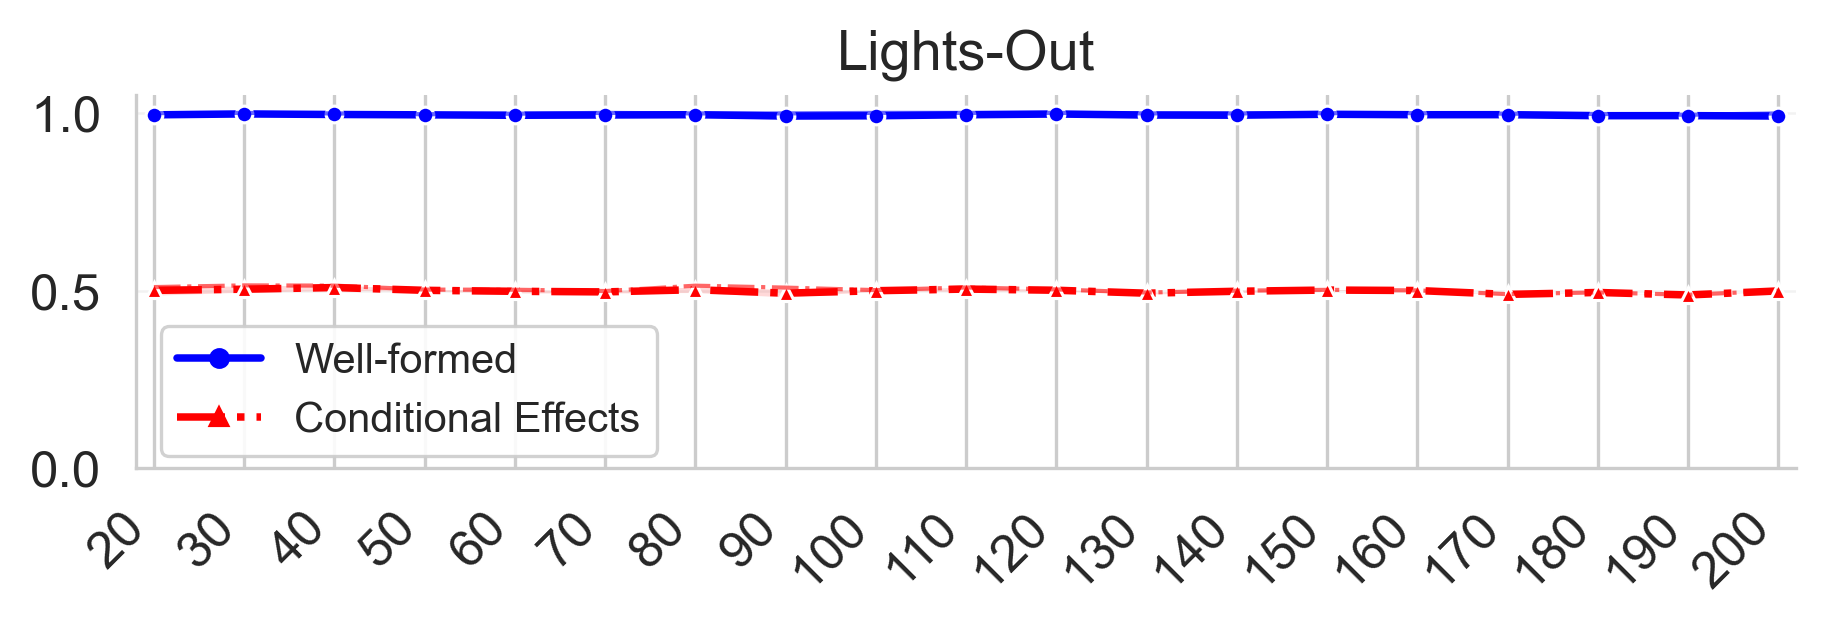

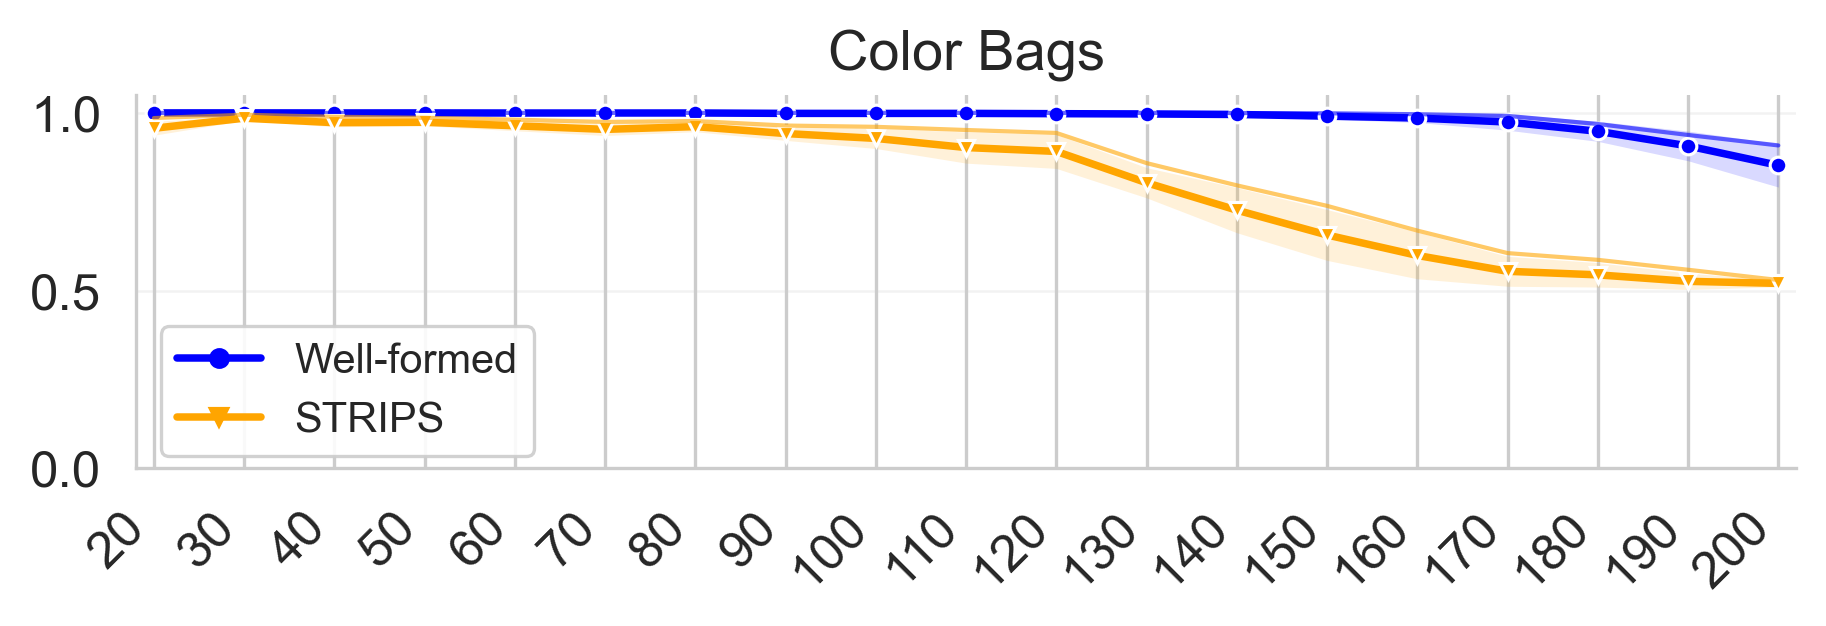

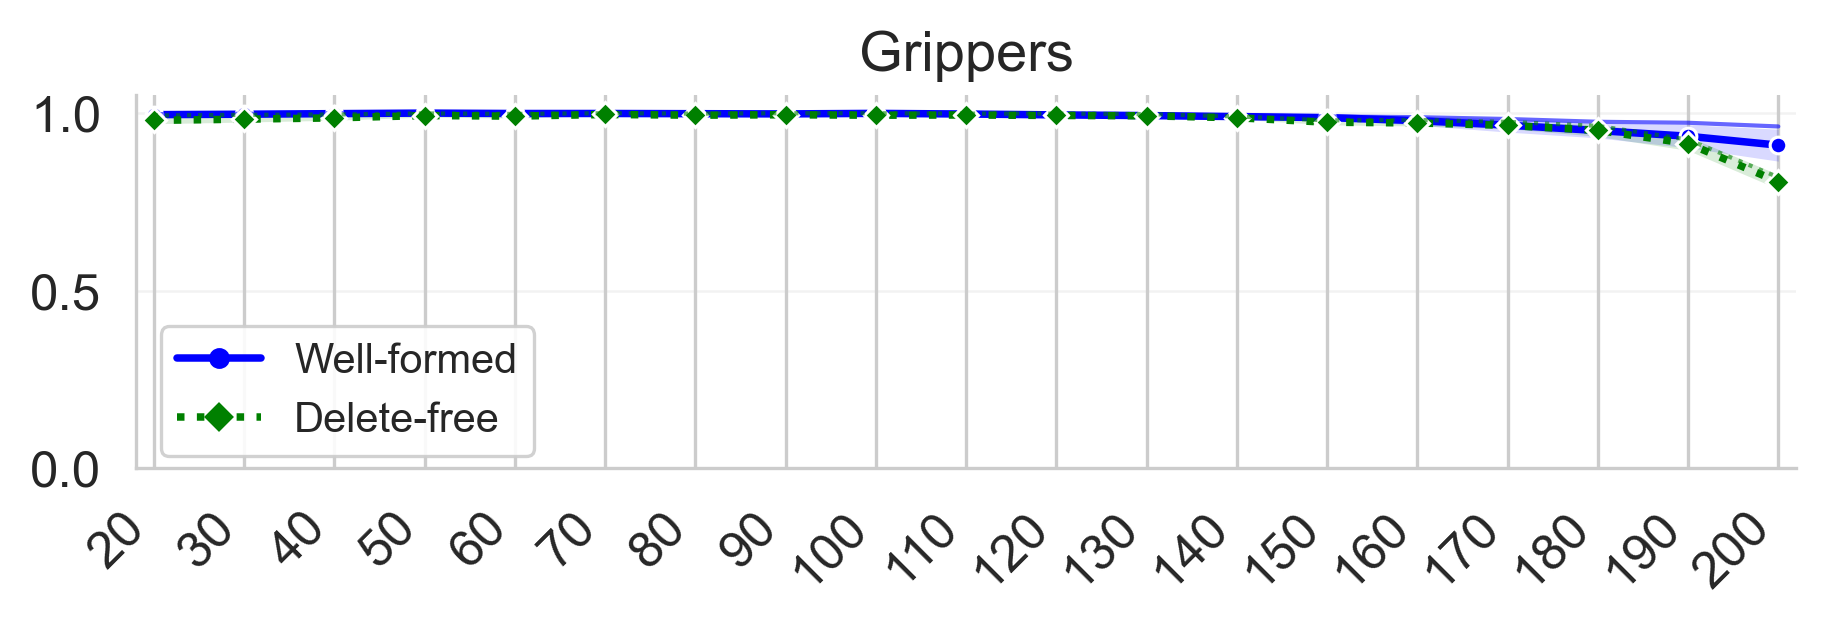

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- Seaborn styling (match collaborator) ----------------
sns.set_theme(
    context="paper",
    style="whitegrid",
    font="sans-serif",
    font_scale=1.4,
)
plt.rcParams.update(
    {
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "legend.fontsize": 10,
        "legend.frameon": True,
        "legend.fancybox": True,
        "legend.edgecolor": "0.8",
        "legend.framealpha": 0.9,
    }
)

# ----- Display names -----
TASK_NAME_MAP = {
    "color_bag": "Color Bags",
    "lights_out": "Lights-Out",
    "grippers": "Grippers",
}

VARIANT_NAME_MAP = {
    "wf": "Well-formed",
    "nwf": "Not-well-formed",
    "df": "Delete-free",
    "Conditional Effects": "Conditional Effects",
    "STRIPS": "STRIPS",
}

# ----- Styles (keyed by *display* name) -----
variant_styles = {
    "Well-formed":         {"color": "blue",   "marker": "o", "linestyle": "-",  "linewidth": 1.8},
    "Not-well-formed":     {"color": "#d62728","marker": "s", "linestyle": "--", "linewidth": 1.8},
    "Delete-free":         {"color": "green",  "marker": "D", "linestyle": ":",  "linewidth": 1.8},
    "Conditional Effects": {"color": "red",    "marker": "^", "linestyle": "-.", "linewidth": 1.8},
    "STRIPS":              {"color": "orange", "marker": "v", "linestyle": "-",  "linewidth": 1.8},
}

DATASET_ORDER = ["lights_out", "color_bag", "grippers"]

def display_variant_name(raw_key: str) -> str:
    return VARIANT_NAME_MAP.get(raw_key, raw_key)

def style_for_variant(display_name: str, fallback_idx: int = 0):
    if display_name in variant_styles:
        return variant_styles[display_name]
    # fallback: seaborn palette
    palette = sns.color_palette()
    color = palette[fallback_idx % len(palette)]
    return {"color": color, "marker": "o", "linestyle": "-", "linewidth": 1.8}

for dataset_key in DATASET_ORDER:
    if dataset_key not in bucket_df_dict:
        continue

    variant_dict = bucket_df_dict[dataset_key]
    if not variant_dict:
        continue

    present_variant_keys = list(variant_dict.keys())

    # buckets -> x positions
    all_buckets = sorted({int(b) for v in variant_dict.values() for b in v["bucket"]})
    bucket_to_idx = {b: i for i, b in enumerate(all_buckets)}
    x = np.arange(len(all_buckets))
    x_labels = [str(b) for b in all_buckets]

    fig, ax = plt.subplots(figsize=(6, 2))

    legend_handles = []
    for j, variant_key in enumerate(present_variant_keys):
        stats = variant_dict[variant_key]

        idx = np.array([bucket_to_idx[int(b)] for b in stats["bucket"]], dtype=int)
        y_mean = stats["mean"].to_numpy()
        y_std  = stats["std"].to_numpy()
        y_best = stats["best"].to_numpy()

        name = display_variant_name(variant_key)
        st = style_for_variant(name, fallback_idx=j)
        color = st["color"]
        marker = st.get("marker", "o")
        linestyle = st.get("linestyle", "-")
        lw = st.get("linewidth", 1.8)

        # Use seaborn to draw the mean line (styling consistent with theme)
        sns.lineplot(
            x=idx, y=y_mean, ax=ax,
            color=color, linestyle=linestyle, linewidth=lw,
            marker=marker, markersize=4,
            label=name,
        )

        # Std band (still easiest in matplotlib)
        ax.fill_between(
            idx, y_mean - y_std, y_mean + y_std,
            color=color, alpha=0.15, linewidth=0
        )

        # Best curve (thin)
        ax.plot(idx, y_best, color=color, linestyle=linestyle, linewidth=1.0, alpha=0.6)

        # Legend handle (ensures legend matches your explicit style)
        legend_handles.append(
            plt.Line2D(
                [0], [0],
                color=color, marker=marker, linestyle=linestyle,
                linewidth=lw, markersize=4, label=name
            )
        )

    ax.set_title(f"{TASK_NAME_MAP.get(dataset_key, dataset_key)}")

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha="right")
    ax.set_xlim(-0.2, len(all_buckets) - 0.8)
    ax.set_ylim(0.0, 1.05)

    # If you want less grid intensity than seaborn default:
    ax.grid(True, axis="y", alpha=0.25, linewidth=0.6)

    ax.legend(
        handles=legend_handles,
        loc="lower left",
        bbox_to_anchor=(0.01, 0.01),
        borderaxespad=0.2,
        title=None,
    )

    fig.tight_layout(pad=0.3)
    plt.show()
